# Step 5B — Joint VAE (Model B)

**Key difference from 01_vae_classifier**: single-phase training that jointly optimises
classification (source), reconstruction (both), KL (both), and MMD (source μ vs target μ).
The classifier head reads `μ` directly (deterministic — no sampling noise at inference time).

| Loss | Weight | Data |
|---|---|---|
| CE (cross-entropy, class-weighted) | 1.0 | source only |
| Reconstruction MSE | 1.0 | source + target |
| KL divergence | 0.1 (β=0.1) | source + target |
| MMD (μ_src ‖ μ_tgt) | 0→0.3 ramp | both |

**MMD ramp**: weight=0 for epochs 0–4, linearly 0→0.3 for epochs 5–20, fixed 0.3 thereafter.

In [6]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step5_vae' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data Loading + CORAL Alignment

In [7]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight_dict = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}
class_weight_vec  = np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32)

print(f'Source train: {X_train.shape}  Target: {X_target_raw.shape}')
print(f'n_genes={n_genes}  classes={class_names}')
print(f'Class weights: {class_weight_dict}')

Source train: (6824, 3000)  Target: (63877, 3000)
n_genes=3000  classes=['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']
Class weights: {0: np.float64(0.5908225108225108), 1: np.float64(1.7102756892230577), 2: np.float64(1.2665181885671863), 3: np.float64(0.885773624091381), 4: np.float64(2.016548463356974), 5: np.float64(0.764336917562724)}


In [8]:
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0] - 1) + reg * np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0] - 1) + reg * np.eye(Xt.shape[1])

    def mat_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T

    def mat_inv_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(1.0 / np.sqrt(np.maximum(v, 1e-10))) @ V.T

    W = mat_inv_sqrt(Ct) @ mat_sqrt(Cs)
    return ((Xt @ W) + src_mean).astype(np.float32)

print('Running CORAL alignment...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
print(f'CORAL done. Target eval subset: {X_target_eval.shape}')

Running CORAL alignment...
CORAL done. Target eval subset: (12776, 3000)


## 2. tf.data Pipelines

Source batches carry `(X, y)`. Target batches carry `X` only.
We zip them so each train step sees one source batch and one target batch simultaneously.

In [9]:
BATCH_SIZE = 256
RAMP_START = 5    # epoch at which MMD weight starts ramping
RAMP_END   = 20   # epoch at which MMD weight reaches MAX_MMD_W
MAX_MMD_W  = 0.3

# Source dataset — (X, y) pairs
src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train.astype(np.int32)))
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE)
    .repeat()
)

# Target dataset — X only (unlabelled)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices(X_target_coral)
    .shuffle(80000, seed=42)
    .batch(BATCH_SIZE)
    .repeat()
)

# Zipped: each element is ((X_src, y_src), X_tgt)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))

steps_per_epoch = len(X_train) // BATCH_SIZE
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test.astype(np.int32))).batch(BATCH_SIZE)

print(f'Steps per epoch: {steps_per_epoch}')
print(f'Source batches × {BATCH_SIZE} = {steps_per_epoch * BATCH_SIZE} source samples / epoch')

Steps per epoch: 26
Source batches × 256 = 6656 source samples / epoch


## 3. Joint VAE Model

Architecture:
```
X_src ──► Encoder ──► μ_src, logvar_src, z_src ──► Decoder ──► X̂_src
                   └──► Classifier head ──► p(y|μ_src)

X_tgt ──► Encoder ──► μ_tgt, logvar_tgt, z_tgt ──► Decoder ──► X̂_tgt
```

Losses (all in `train_step`):
1. `ce_loss`    = class-weighted cross-entropy on (μ_src, y_src)
2. `recon_loss` = MSE reconstruction averaged over source + target
3. `kl_loss`    = KL divergence averaged over source + target (β=0.1)
4. `mmd_loss`   = multi-scale RBF MMD between μ_src and μ_tgt (ramped)

In [10]:
LATENT_DIM = 128
BETA       = 0.1   # lower β keeps reconstruction signal strong during joint training

class Sampling(layers.Layer):
    """Reparameterisation trick: z = μ + ε·σ, ε ~ N(0,1)."""
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps


def build_encoder(input_dim, latent_dim):
    inp   = keras.Input(shape=(input_dim,), name='encoder_input')
    x     = layers.Dense(512, activation='relu')(inp)
    x     = layers.LayerNormalization()(x)
    x     = layers.Dropout(0.3)(x)
    x     = layers.Dense(256, activation='relu')(x)
    x     = layers.LayerNormalization()(x)
    x     = layers.Dropout(0.2)(x)
    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z       = Sampling(name='z')([mu, log_var])
    return keras.Model(inp, [mu, log_var, z], name='encoder')


def build_decoder(latent_dim, output_dim):
    inp = keras.Input(shape=(latent_dim,), name='decoder_input')
    x   = layers.Dense(256, activation='relu')(inp)
    x   = layers.LayerNormalization()(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.LayerNormalization()(x)
    out = layers.Dense(output_dim, activation='linear', name='reconstruction')(x)
    return keras.Model(inp, out, name='decoder')


def build_classifier(latent_dim, n_classes):
    inp = keras.Input(shape=(latent_dim,), name='clf_input')
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.LayerNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)
    return keras.Model(inp, out, name='classifier')


print('Building sub-networks...')
encoder    = build_encoder(n_genes, LATENT_DIM)
decoder    = build_decoder(LATENT_DIM, n_genes)
classifier = build_classifier(LATENT_DIM, n_classes)
encoder.summary()
print(f'Latent dim: {LATENT_DIM}  β={BETA}')

Building sub-networks...


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,536,512 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512)       │      1,024 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 128)       │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,735,168 (6.62 MB)

 Trainable params: 1,735,168 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

Latent dim: 128  β=0.1


In [11]:
def mmd_rbf(x, y, sigmas):
    """Multi-scale RBF MMD between rows of x and y."""
    def rbf_kernel(a, b, sigma):
        diff = tf.expand_dims(a, 1) - tf.expand_dims(b, 0)   # (n, m, d)
        sq   = tf.reduce_sum(tf.square(diff), axis=-1)        # (n, m)
        return tf.exp(-sq / (2.0 * sigma ** 2))

    loss = tf.constant(0.0)
    for s in sigmas:
        kxx = tf.reduce_mean(rbf_kernel(x, x, s))
        kyy = tf.reduce_mean(rbf_kernel(y, y, s))
        kxy = tf.reduce_mean(rbf_kernel(x, y, s))
        loss += kxx + kyy - 2.0 * kxy
    return loss / float(len(sigmas))


class JointVAE(keras.Model):
    def __init__(self, encoder, decoder, classifier, n_classes,
                 class_weight_vec, beta=0.1, max_mmd_w=0.3,
                 ramp_start=5, ramp_end=20, mmd_sigmas=None, **kwargs):
        super().__init__(**kwargs)
        self.encoder    = encoder
        self.decoder    = decoder
        self.classifier = classifier
        self.n_classes  = n_classes
        self.beta       = beta
        self.max_mmd_w  = max_mmd_w
        self.ramp_start = float(ramp_start)
        self.ramp_end   = float(ramp_end)
        self.mmd_sigmas = mmd_sigmas or [1.0, 5.0, 10.0, 20.0]
        # class weights as a constant tensor  (n_classes,)
        self.cw = tf.constant(class_weight_vec, dtype=tf.float32)

        # tf.Variable tracks the current epoch so the ramp works inside graph mode
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        self.total_tracker = keras.metrics.Mean(name='loss')
        self.ce_tracker    = keras.metrics.Mean(name='ce_loss')
        self.recon_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_tracker    = keras.metrics.Mean(name='kl_loss')
        self.mmd_tracker   = keras.metrics.Mean(name='mmd_loss')
        self.acc_tracker   = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    @property
    def metrics(self):
        return [self.total_tracker, self.ce_tracker, self.recon_tracker,
                self.kl_tracker, self.mmd_tracker, self.acc_tracker]

    def _mmd_weight(self):
        ep = self.current_epoch
        # 0 before ramp_start, linearly 0→max_mmd_w from ramp_start to ramp_end
        progress = tf.clip_by_value(
            (ep - self.ramp_start) / (self.ramp_end - self.ramp_start + 1e-8),
            0.0, 1.0
        )
        return progress * self.max_mmd_w

    def _kl(self, mu, log_var):
        return -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        )

    def _recon(self, x, x_hat):
        return tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=1))

    def train_step(self, data):
        (x_src, y_src), x_tgt = data
        with tf.GradientTape() as tape:
            # --- encode both domains ---
            mu_src, lv_src, z_src = self.encoder(x_src, training=True)
            mu_tgt, lv_tgt, z_tgt = self.encoder(x_tgt, training=True)

            # --- decode both domains ---
            xhat_src = self.decoder(z_src, training=True)
            xhat_tgt = self.decoder(z_tgt, training=True)

            # --- classify on μ_src (deterministic, no sampling noise) ---
            y_pred = self.classifier(mu_src, training=True)

            # 1) class-weighted CE
            sample_w = tf.gather(self.cw, y_src)
            ce_loss  = tf.reduce_mean(
                sample_w * tf.keras.losses.sparse_categorical_crossentropy(y_src, y_pred)
            )

            # 2) reconstruction (source + target, averaged)
            recon_loss = 0.5 * (self._recon(x_src, xhat_src) + self._recon(x_tgt, xhat_tgt))

            # 3) KL (source + target, averaged)
            kl_loss = 0.5 * (self._kl(mu_src, lv_src) + self._kl(mu_tgt, lv_tgt))

            # 4) MMD on means only (deterministic latent alignment)
            mmd_loss = mmd_rbf(mu_src, mu_tgt, self.mmd_sigmas)

            mmd_w = self._mmd_weight()
            total = ce_loss + 1.0 * recon_loss + self.beta * kl_loss + mmd_w * mmd_loss

        grads = tape.gradient(total, self.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_tracker.update_state(total)
        self.ce_tracker.update_state(ce_loss)
        self.recon_tracker.update_state(recon_loss)
        self.kl_tracker.update_state(kl_loss)
        self.mmd_tracker.update_state(mmd_loss)
        self.acc_tracker.update_state(y_src, y_pred)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        # validation: source (X, y) only
        x, y = data
        mu, _, _ = self.encoder(x, training=False)
        xhat     = self.decoder(mu, training=False)   # use μ at inference
        y_pred   = self.classifier(mu, training=False)

        sample_w   = tf.gather(self.cw, y)
        ce_loss    = tf.reduce_mean(
            sample_w * tf.keras.losses.sparse_categorical_crossentropy(y, y_pred)
        )
        recon_loss = self._recon(x, xhat)
        kl_loss    = tf.constant(0.0)   # skip KL in val for simplicity
        mmd_loss   = tf.constant(0.0)
        total      = ce_loss + 1.0 * recon_loss

        self.total_tracker.update_state(total)
        self.ce_tracker.update_state(ce_loss)
        self.recon_tracker.update_state(recon_loss)
        self.kl_tracker.update_state(kl_loss)
        self.mmd_tracker.update_state(mmd_loss)
        self.acc_tracker.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

    def call(self, x, training=False):
        mu, _, _ = self.encoder(x, training=training)
        return self.classifier(mu, training=training)


print('JointVAE class defined.')

JointVAE class defined.


## 4. Calibrate MMD σ on the Latent Space

We sample 500 points from a quick forward pass of X_train through a freshly initialised encoder,
compute pairwise distances, and set σ to quartiles of the median distance.

In [12]:
# Build the model first so the encoder weights are initialised
model = JointVAE(
    encoder, decoder, classifier,
    n_classes=n_classes,
    class_weight_vec=class_weight_vec,
    beta=BETA,
    max_mmd_w=MAX_MMD_W,
    ramp_start=RAMP_START,
    ramp_end=RAMP_END,
    name='joint_vae',
)
model.compile(optimizer=keras.optimizers.Adam(1e-4, clipnorm=1.0))

# Calibrate σ on a 500-sample subset of the source training set
idx_sub = np.random.choice(len(X_train), 500, replace=False)
mu_sub, _, _ = encoder.predict(X_train[idx_sub], batch_size=256, verbose=0)

diffs  = mu_sub[:, None, :] - mu_sub[None, :, :]             # (500, 500, d)
dists  = np.sqrt((diffs**2).sum(axis=-1))                     # (500, 500)
upper  = dists[np.triu_indices(500, k=1)]
med    = float(np.median(upper))
SIGMAS = [med / 4, med / 2, med, med * 2]

model.mmd_sigmas = SIGMAS
print(f'Median pairwise μ-distance: {med:.4f}')
print(f'Calibrated σ values: {[f"{s:.4f}" for s in SIGMAS]}')

Median pairwise μ-distance: 18.4368
Calibrated σ values: ['4.6092', '9.2184', '18.4368', '36.8736']


## 5. Callbacks

In [13]:
class EpochRampCallback(keras.callbacks.Callback):
    """Updates model.current_epoch tf.Variable at the start of each epoch."""
    def on_epoch_begin(self, epoch, logs=None):
        self.model.current_epoch.assign(float(epoch))


callbacks = [
    EpochRampCallback(),
    keras.callbacks.EarlyStopping(
        monitor='val_ce_loss', mode='min',
        patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_ce_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]
print('Callbacks ready.')

Callbacks ready.


## 6. Training

In [14]:
EPOCHS = 80

history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.1923 - ce_loss: 2.5907 - kl_loss: 191.2017 - loss: 3580.4727 - mmd_loss: 0.0051 - recon_loss: 3558.7615 - val_accuracy: 0.1934 - val_ce_loss: 2.2318 - val_kl_loss: 0.0000e+00 - val_loss: 3602.5210 - val_mmd_loss: 0.0000e+00 - val_recon_loss: 3600.2888 - learning_rate: 1.0000e-04
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.1868 - ce_loss: 2.4389 - kl_loss: 195.7163 - loss: 3348.1196 - mmd_loss: 0.0058 - recon_loss: 3326.1089 - val_accuracy: 0.1964 - val_ce_loss: 2.0082 - val_kl_loss: 0.0000e+00 - val_loss: 3287.8269 - val_mmd_loss: 0.0000e+00 - val_recon_loss: 3285.8188 - learning_rate: 1.0000e-04
Epoch 3/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.2144 - ce_loss: 2.1427 - kl_loss: 218.9418 - loss: 3108.4634 - mmd_loss: 0.0085 - recon_loss: 3084.4268 - val_accuracy: 0.2468 - val_ce_loss: 1.6456 - val_kl_loss: 0.0000e+00 - val_loss: 3020.1306 - val_mmd_loss: 0.0000e+00 - val_recon_loss: 301

## 7. Training Curves

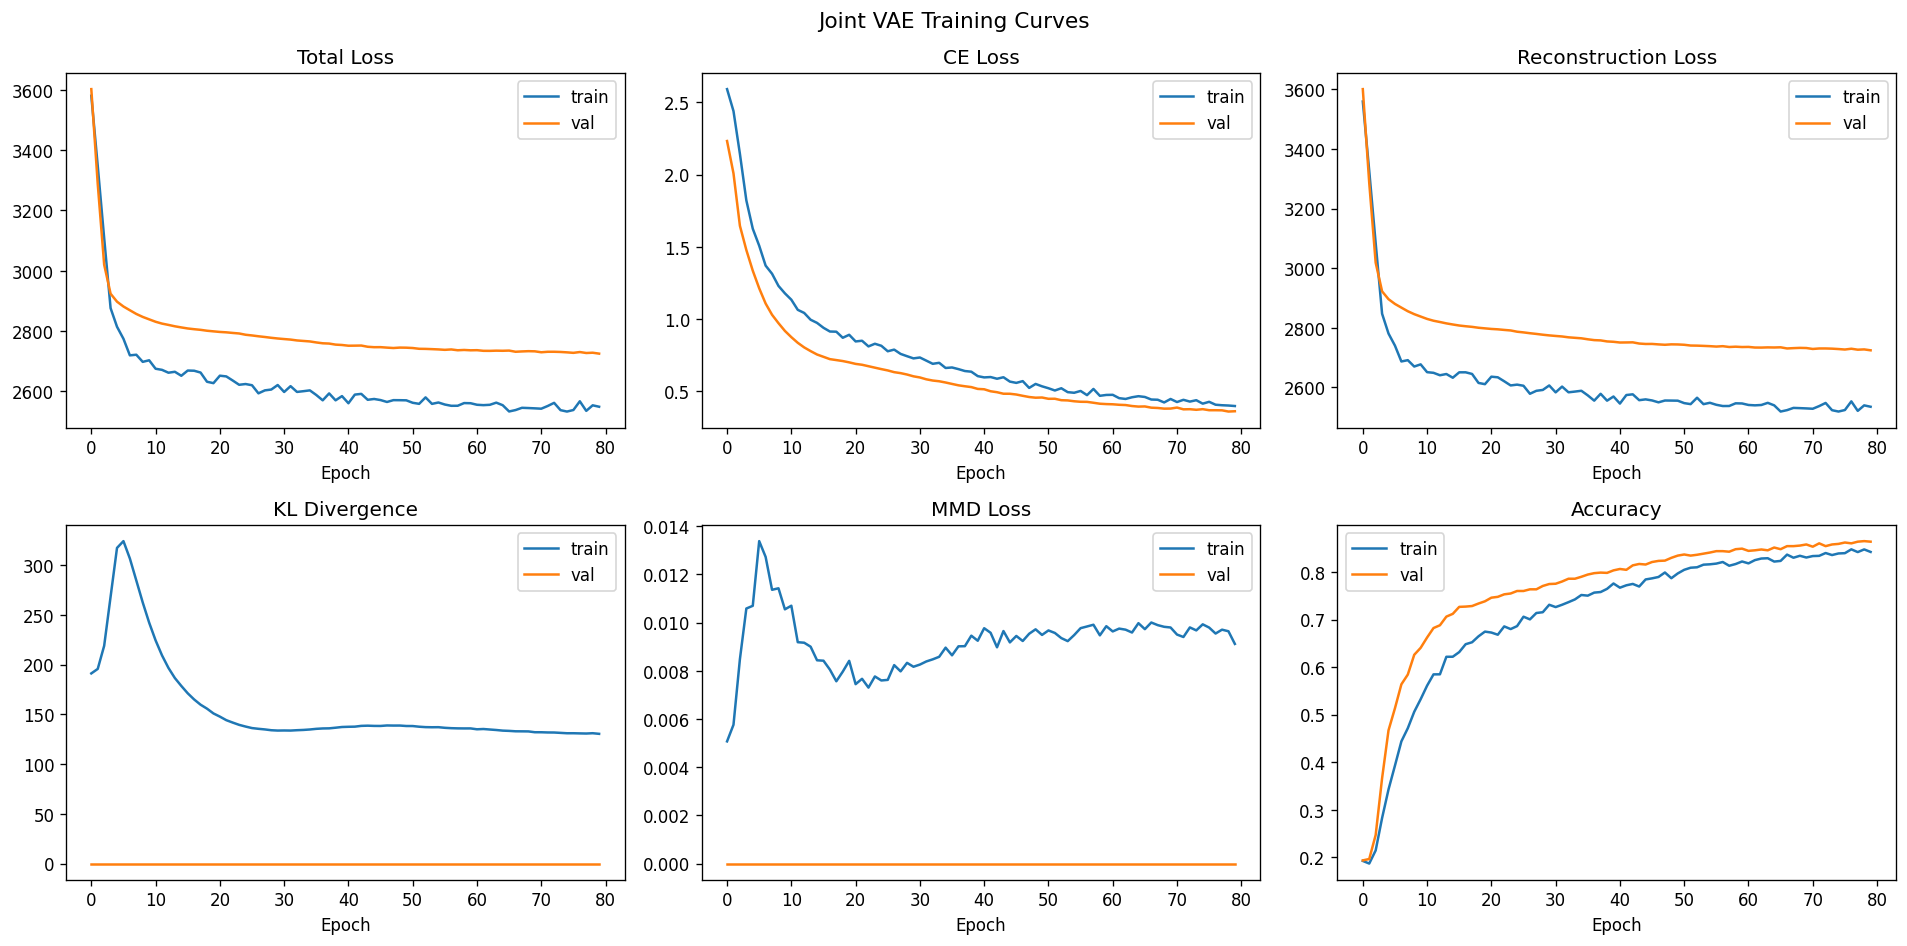

Trained for 80 epochs.


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = [
    ('loss',       'val_loss',       'Total Loss'),
    ('ce_loss',    'val_ce_loss',    'CE Loss'),
    ('recon_loss', 'val_recon_loss', 'Reconstruction Loss'),
    ('kl_loss',    'val_kl_loss',    'KL Divergence'),
    ('mmd_loss',   'val_mmd_loss',   'MMD Loss'),
    ('accuracy',   'val_accuracy',   'Accuracy'),
]
for ax, (train_key, val_key, title) in zip(axes.flat, metrics):
    ax.plot(history.history[train_key], label='train')
    if val_key in history.history:
        ax.plot(history.history[val_key], label='val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('Joint VAE Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'joint_vae_training_curves.png', bbox_inches='tight')
plt.show()
print(f'Trained for {len(history.history["loss"])} epochs.')

## 8. Evaluate — Source Test

In [16]:
y_pred_src = np.argmax(model.predict(X_test, batch_size=256), axis=1)
src_f1 = f1_score(y_test, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test, y_pred_src, target_names=class_names))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Source Test Macro F1: 0.8532
              precision    recall  f1-score   support

    Effector       0.93      0.89      0.91       482
   Exhausted       0.81      0.98      0.88       166
       Naive       0.76      0.89      0.82       224
   Other_CD4       0.83      0.73      0.77       321
    Th1-like       0.78      0.83      0.80       141
        Treg       0.96      0.90      0.93       372

    accuracy                           0.87      1706
   macro avg       0.84      0.87      0.85      1706
weighted avg       0.87      0.87      0.87      1706



## 9. Evaluate — Target Domain

In [17]:
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=256), axis=1)
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Domain Macro F1: {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Target Domain Macro F1: 0.3816
              precision    recall  f1-score   support

    Effector       0.56      0.49      0.52      2839
   Exhausted       0.05      0.08      0.06       903
       Naive       0.82      0.51      0.63      3806
   Other_CD4       0.38      0.31      0.34      2127
    Th1-like       0.15      0.27      0.19      1031
        Treg       0.46      0.66      0.54      2070

    accuracy                           0.45     12776
   macro avg       0.40      0.39      0.38     12776
weighted avg       0.52      0.45      0.47     12776



## 10. Confusion Matrices

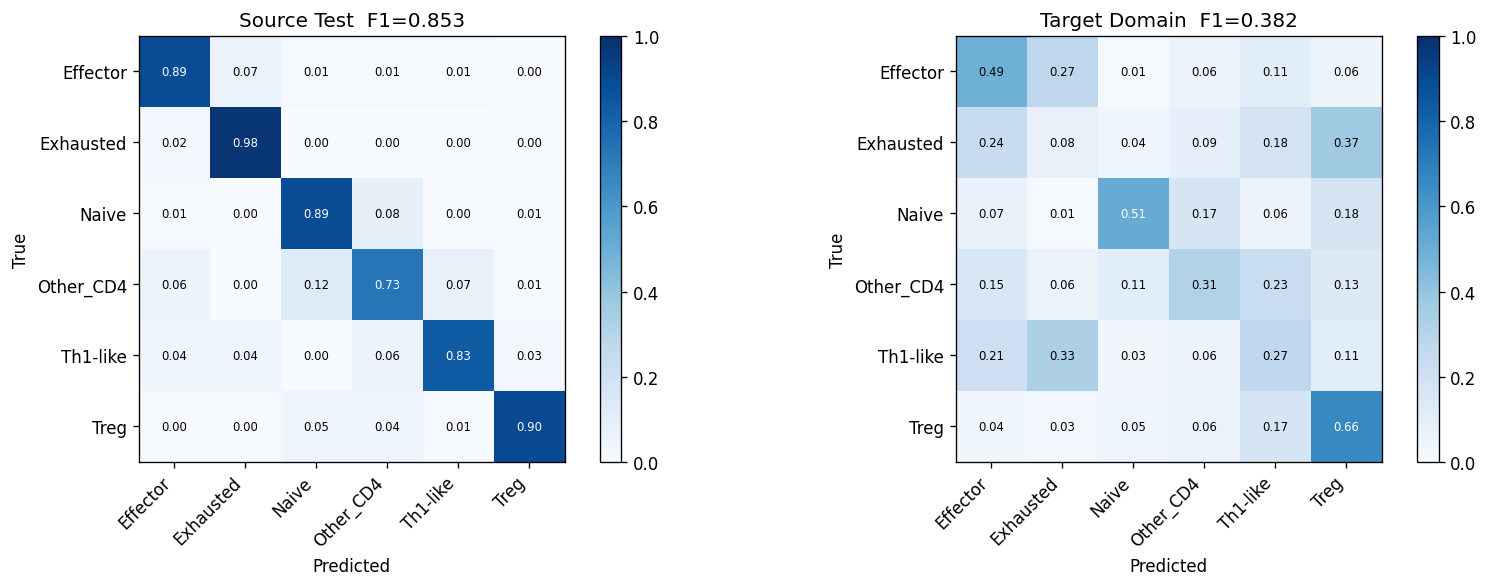

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source Test  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain  F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'joint_vae_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 11. Latent Space t-SNE: Joint VAE vs Original VAE

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Running t-SNE on Joint VAE latent space...


/var/folders/28/r1zy7hp93zb8w_dtfdjsms6r0000gn/T/ipykernel_75298/4289494789.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes)


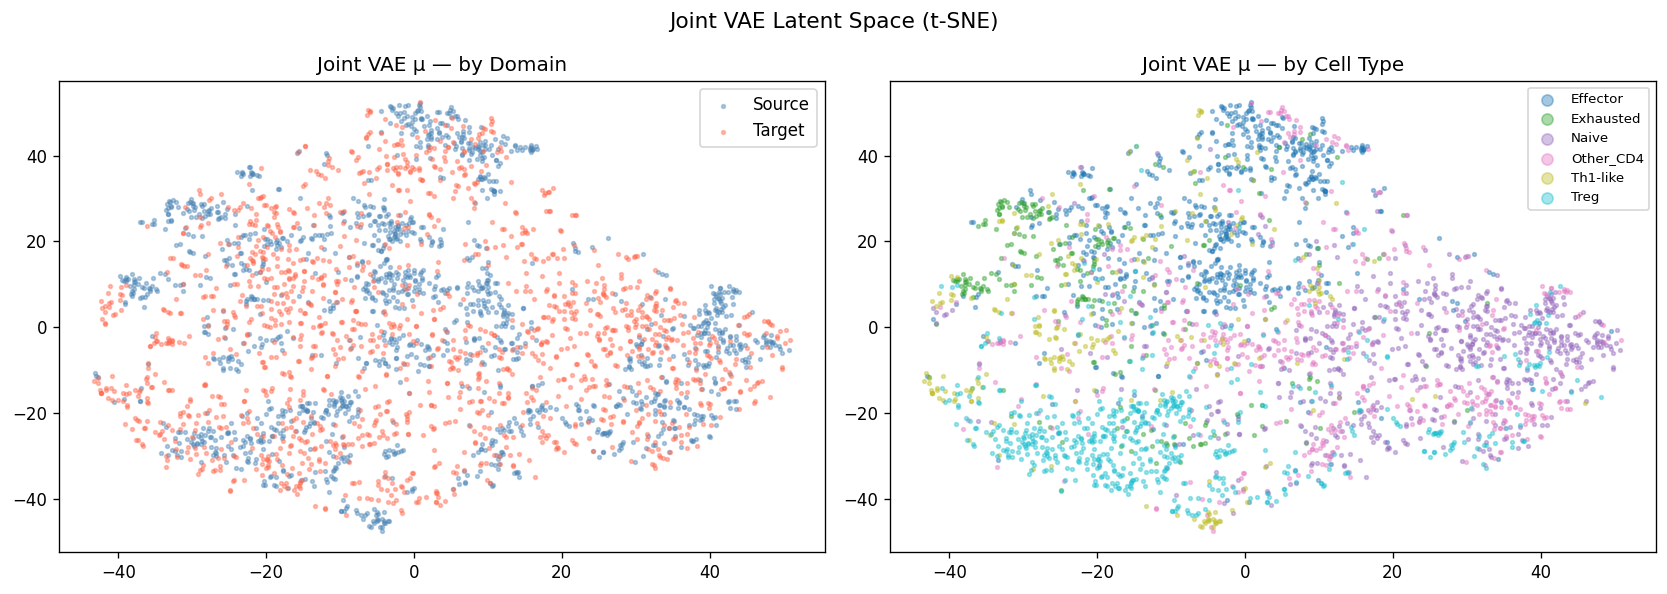

In [19]:
from sklearn.manifold import TSNE

# μ from Joint VAE encoder
mu_src_jv, _, _ = encoder.predict(X_test,        batch_size=256)
mu_tgt_jv, _, _ = encoder.predict(X_target_eval, batch_size=256)

N_VIZ = 1500   # subsample for speed
idx_s = np.random.choice(len(mu_src_jv), min(N_VIZ, len(mu_src_jv)), replace=False)
idx_t = np.random.choice(len(mu_tgt_jv), min(N_VIZ, len(mu_tgt_jv)), replace=False)

mu_all     = np.concatenate([mu_src_jv[idx_s], mu_tgt_jv[idx_t]], axis=0)
domain_all = np.array([0]*len(idx_s) + [1]*len(idx_t))
labels_all = np.concatenate([y_test[idx_s], y_target_eval[idx_t]], axis=0)

print('Running t-SNE on Joint VAE latent space...')
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
z2d  = tsne.fit_transform(mu_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_d = ['steelblue', 'tomato']
for d, lbl in [(0, 'Source'), (1, 'Target')]:
    m = domain_all == d
    axes[0].scatter(z2d[m, 0], z2d[m, 1], c=colors_d[d], alpha=0.4, s=5, label=lbl)
axes[0].set_title(f'Joint VAE μ — by Domain'); axes[0].legend()

cmap = plt.cm.get_cmap('tab10', n_classes)
for ci, cn in enumerate(class_names):
    m = labels_all == ci
    axes[1].scatter(z2d[m, 0], z2d[m, 1], c=[cmap(ci)], alpha=0.4, s=5, label=cn)
axes[1].set_title('Joint VAE μ — by Cell Type')
axes[1].legend(markerscale=3, fontsize=8)

plt.suptitle('Joint VAE Latent Space (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'joint_vae_latent_tsne.png', bbox_inches='tight')
plt.show()

## 12. Full Comparison Table + Save Results

In [20]:
src_report = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'JointVAE',
    'config': {
        'latent_dim': LATENT_DIM,
        'beta': BETA,
        'max_mmd_weight': MAX_MMD_W,
        'ramp_start_epoch': RAMP_START,
        'ramp_end_epoch': RAMP_END,
        'mmd_sigmas': SIGMAS,
        'epochs_trained': len(history.history['loss']),
        'coral_aligned': True,
        'class_weighted': True,
        'joint_training': True,
        'classifier_on_mu': True,
    },
    'source_test': {
        'macro_f1': float(src_f1),
        'accuracy': float(accuracy_score(y_test, y_pred_src)),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1': float(tgt_f1),
        'accuracy': float(accuracy_score(y_target_eval, y_pred_tgt)),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
}
with open(RESULTS_DIR / 'joint_vae_results.json', 'w') as f:
    json.dump(results, f, indent=2)

encoder.save(str(RESULTS_DIR / 'joint_vae_encoder.keras'))
classifier.save(str(RESULTS_DIR / 'joint_vae_classifier.keras'))

# ── Full comparison table ────────────────────────────────────────────────────
all_models = [
    ('LogReg',                       0.885,   None),
    ('MLP',                          0.884,   None),
    ('MMD-Net',                      None,    0.194),
    ('DANN v1',                      0.852,   0.391),
    ('DANN v2',                      0.875,   0.395),
    ('GeneAtt v1 (no align)',        0.894,   0.079),
    ('GeneAtt v2 (CORAL+MMD)',       0.893,   0.404),
    ('PatchTransformer (CORAL+MMD)', 0.772,   0.384),
    ('VAE + Classifier (2-phase)',   0.881,   0.383),
    ('Joint VAE',                    src_f1,  tgt_f1),
]

best_tgt = max(t for _, _, t in all_models if t is not None)
print(f'\n{"Model":35s} {"Source F1":>10s} {"Target F1":>10s}')
print('-' * 60)
for name, sf, tf_ in all_models:
    s = f'{sf:.3f}' if sf is not None else '   —  '
    t = f'{tf_:.3f}' if tf_ is not None else '   —  '
    marker = ' ◄ best' if tf_ is not None and abs(tf_ - best_tgt) < 1e-9 else ''
    print(f'{name:35s} {s:>10s} {t:>10s}{marker}')


Model                                Source F1  Target F1
------------------------------------------------------------
LogReg                                   0.885        —  
MLP                                      0.884        —  
MMD-Net                                    —        0.194
DANN v1                                  0.852      0.391
DANN v2                                  0.875      0.395
GeneAtt v1 (no align)                    0.894      0.079
GeneAtt v2 (CORAL+MMD)                   0.893      0.404 ◄ best
PatchTransformer (CORAL+MMD)             0.772      0.384
VAE + Classifier (2-phase)               0.881      0.383
Joint VAE                                0.853      0.382
